In [4]:
# Import necessary packages
import straindesign as sd
import cobra

# If available, set the solver to cplex or gurobi. This will increase the chances
# of sucess enormously
cobra.Configuration().solver = 'gurobi'

# import the microorganism metabolic model
coli = cobra.io.load_model('iML1515')

# Create copy of model to which pathway will be added
coli_PHB = coli.copy()


#coli_PHB.solver = 'gurobi'



# Glucose, glycerol, xylose, and oxygen uptake
coli_PHB.reactions.EX_glc__D_e.bounds = -10.5, 1000
#coli_PHB.reactions.EX_glyc_e.bounds = -13, 1000
#coli_PHB.reactions.EX_xyl__D_e.bounds = -7.5, 1000
coli_PHB.reactions.EX_o2_e.bounds = -15, 1000


# Add metabolites to model
coli_PHB.add_metabolites([ cobra.Metabolite('3hbcoa__R_c'),   # (R)-3-hydroxybutyryl-CoA
                            cobra.Metabolite('3hb_c'),# 3-hydroxybutyrate (cytopl.)
                            cobra.Metabolite('3hb_p'), # 3-hydroxybutyrate (peripl.)
                            cobra.Metabolite('3hb_e'), # 3-hydroxybutyrate (extrac.)
                            ])

# Create reactions
AACOAr    = cobra.Reaction('AACOAr')
PHB       = cobra.Reaction('PHB')
PHBtpp    = cobra.Reaction('PHBtpp')
PHBtex    = cobra.Reaction('PHBtex')
EX_3hb_e  = cobra.Reaction('EX_3hb_e')

# Add reactions to model
coli_PHB.add_reactions([AACOAr,
                         PHB,
                         PHBtpp,
                         PHBtex,
                         EX_3hb_e])

# Define reaction equations
AACOAr.reaction     = '1 aacoa_c + 1 nadph_c + 1 h_c <--> 1 3hbcoa__R_c + 1 nadp_c'
PHB.reaction        = '1 3hbcoa__R_c -> 1 3hb_c + 1 coa_c'
PHBtpp.reaction     = '1 3hb_c <--> 1 3hb_p'
PHBtex.reaction     = '1 3hb_p <--> 1 3hb_e'
EX_3hb_e.reaction   = '1 3hb_e <-->'

# Verify that pathway is operational
sol = sd.fba(coli_PHB,obj='EX_3hb_e',obj_sense='max')
print(f"Maximum possible PHB synthesis rate: {sol.objective_value}.")

Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-12
Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpe30ypfd8.lp
Reading time = 0.03 seconds
: 1877 rows, 5424 columns, 21150 nonzeros
Maximum possible PHB synthesis rate: 12.909217391304423.


In [ ]:
# prepare the genome-scale model for the MCS simulation


exchange_reacs = [r for r in coli_PHB.reactions if all(s<0 for s in r.metabolites.values())]
# shut all exchange fluxes
for r in exchange_reacs:
    r.upper_bound = 0.0

# shut CO2 uptake
coli_PHB.reactions.EX_co2_e.lower_bound    = 0.0

# keep main fermentation products open
coli_PHB.reactions.EX_3hb_e.upper_bound  = 1000.0
coli_PHB.reactions.EX_ac_e.upper_bound     = 1000.0
coli_PHB.reactions.EX_co2_e.upper_bound    = 1000.0
coli_PHB.reactions.EX_etoh_e.upper_bound   = 1000.0
coli_PHB.reactions.EX_for_e.upper_bound    = 1000.0
coli_PHB.reactions.EX_h2_e.upper_bound     = 1000.0
coli_PHB.reactions.EX_h2o2_e.upper_bound   = 1000.0
coli_PHB.reactions.EX_h2o_e.upper_bound    = 1000.0
coli_PHB.reactions.EX_h_e.upper_bound      = 1000.0
coli_PHB.reactions.EX_lac__D_e.upper_bound = 1000.0
coli_PHB.reactions.EX_meoh_e.upper_bound   = 1000.0
coli_PHB.reactions.EX_o2_e.upper_bound     = 1000.0
coli_PHB.reactions.EX_succ_e.upper_bound   = 1000.0
coli_PHB.reactions.EX_tungs_e.upper_bound  = 1000.0
coli_PHB.reactions.DM_4crsol_c.upper_bound = 1000.0
coli_PHB.reactions.DM_5drib_c.upper_bound  = 1000.0
coli_PHB.reactions.DM_aacald_c.upper_bound = 1000.0
coli_PHB.reactions.DM_amob_c.upper_bound   = 1000.0
coli_PHB.reactions.DM_mththf_c.upper_bound = 1000.0
coli_PHB.reactions.DM_oxam_c.upper_bound   = 1000.0

# substitute GPR rule in ATPS4rpp (all genes occur only in ATPS)
atps_genes = [g for g in coli_PHB.reactions.ATPS4rpp.genes]
coli_PHB.reactions.ATPS4rpp.gene_reaction_rule = str(atps_genes[0])
cobra.manipulation.remove_genes(coli_PHB,atps_genes[1:])
atps_genes[0].name = 'atpX'

# substitute GPR rules in NADH16pp, NADH17pp, NADH18pp (all genes occur only in NADHxxpp and GPR rules are identical)
nuo_genes = [g for g in coli_PHB.reactions.NADH16pp.genes]
coli_PHB.reactions.NADH16pp.gene_reaction_rule = str(nuo_genes[0])
coli_PHB.reactions.NADH17pp.gene_reaction_rule = str(nuo_genes[0])
coli_PHB.reactions.NADH18pp.gene_reaction_rule = str(nuo_genes[0])
cobra.manipulation.remove_genes(coli_PHB,nuo_genes[1:])
nuo_genes[0].name = 'nuoX'

# substitute GPR rules in FRD2, FRD3 (genes occur only in FRD2 and FRD3 and GPR rules are identical)
frd_genes = [g for g in coli_PHB.reactions.FRD2.genes]
coli_PHB.reactions.FRD2.gene_reaction_rule = str(frd_genes[0])
coli_PHB.reactions.FRD3.gene_reaction_rule = str(frd_genes[0])
cobra.manipulation.remove_genes(coli_PHB,frd_genes[1:])
frd_genes[0].name = 'frdX'

# substitute GPR rule in CYTBO3_4pp
cyo_genes = [g for g in coli_PHB.reactions.CYTBO3_4pp.genes]
coli_PHB.reactions.CYTBO3_4pp.gene_reaction_rule = str(cyo_genes[0])
cobra.manipulation.remove_genes(coli_PHB,cyo_genes[1:])
cyo_genes[0].name = 'cyoX'

# substitute GPR rule in THD2pp
pnt_genes = [g for g in coli_PHB.reactions.THD2pp.genes]
coli_PHB.reactions.THD2pp.gene_reaction_rule = str(pnt_genes[0])
cobra.manipulation.remove_genes(coli_PHB,pnt_genes[1:])
pnt_genes[0].name = 'pntX'

# substitute GPR rule in PDH and AKGDH
ace_genes = [g for g in coli_PHB.genes if g.name in ['aceE', 'aceF']]
lpd = [g for g in coli_PHB.genes if g.name == 'lpd'][0]
coli_PHB.reactions.PDH.gene_reaction_rule = str(ace_genes[0])+' and '+str(lpd)
cobra.manipulation.remove_genes(coli_PHB,ace_genes[1:])
ace_genes[0].name = 'aceEF'

# substitute GPR rule in SUCOAS
sucCD_genes = [g for g in coli_PHB.reactions.SUCOAS.genes]
coli_PHB.reactions.SUCOAS.gene_reaction_rule = str(sucCD_genes[0])
cobra.manipulation.remove_genes(coli_PHB,sucCD_genes[1:])
sucCD_genes[0].name = 'sucCD'

# substitute GPR rule in SUCDi
sdh_genes = [g for g in coli_PHB.reactions.SUCDi.genes]
coli_PHB.reactions.SUCDi.gene_reaction_rule = str(sdh_genes[0])
cobra.manipulation.remove_genes(coli_PHB,sdh_genes[1:])
sdh_genes[0].name = 'sdhX'

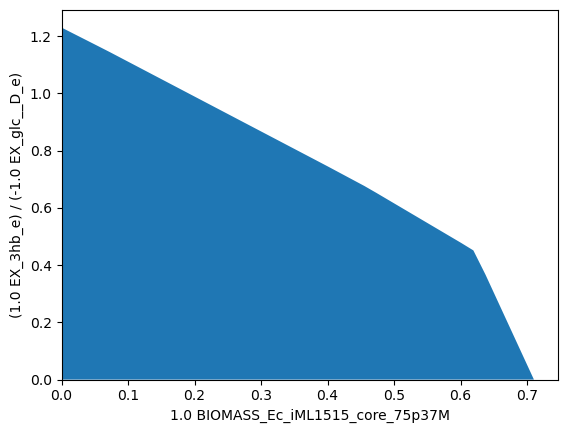

In [ ]:
# plot the yield space

sd.plot_flux_space(coli_PHB, ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')));

In [ ]:
# set the minimum growth rate (h-1) and minimum product yield (mmol/mmol)

min_3hb_yield = 0.75
min_growth = 0.35
module_suppress = sd.SDModule(coli_PHB,sd.names.SUPPRESS,constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0')
module_protect  = sd.SDModule(coli_PHB,sd.names.PROTECT, constraints=f'BIOMASS_Ec_iML1515_core_75p37M>={min_growth}')

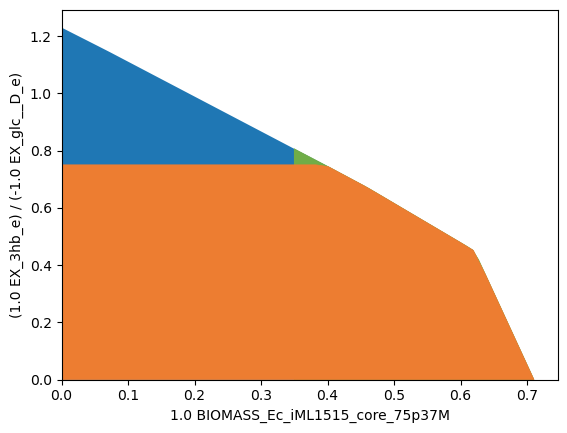

In [ ]:
# plot the are to be protected and area to be suppressed

import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               show=False);
_,          _,      plot2 = sd.plot_flux_space(coli_PHB,
                                               (f'BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               constraints=f'BIOMASS_Ec_iML1515_core_75p37M >= {min_growth}',
                                               show=False);
plot2.set_facecolor('#70AD47')
plot2.set_edgecolor('#70AD47')
# pGCP design plot
_,          _,      plot3 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0',
                                               show=False);
plot3.set_facecolor('#ED7D31')
plot3.set_edgecolor('#ED7D31')
# adjust axes limits and show plot
plot3.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot3.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

In [ ]:
# run he MCS simulation

import logging
logging.basicConfig(level=logging.INFO)

# allow all gene knockouts except for spontanuos
gko_cost = {g.name:1 for g in coli_PHB.genes}
gko_cost.pop('s0001')

# possible knockout of O2
ko_cost = {'EX_o2_e': 1}

# Compute strain designs
sols = sd.compute_strain_designs(coli_PHB,
                                 sd_modules = [module_suppress, module_protect],
                                 max_solutions = 1,
                                 max_cost = 50,
                                 ko_cost = ko_cost,
                                 gko_cost = gko_cost,
                                 solution_approach = sd.names.ANY)
# Print solutions
print(f"One compressed solution with cost {sols.sd_cost[0]} found and "+\
      f"expanded to {len(sols.reaction_sd)} solutions in the uncompressed network.")
print(f"Example intervention set: {['+'+s if v>0 else '-'+s for s,v in sols.gene_sd[0].items() if v!=0]}")

INFO:root:Preparing strain design computation.
INFO:root:  Using gurobi for solving LPs during preprocessing.
INFO:root:  FVA to identify blocked reactions and irreversibilities.
INFO:root:  FVA(s) to identify essential reactions.
INFO:root:Preprocessing GPR rules (1484 genes, 2266 gpr rules).
INFO:root:  Simplifyied to 1229 genes and 1856 gpr rules.
INFO:root:  Extending metabolic network with gpr associations.
INFO:root:Compressing Network (5248 reactions).
INFO:root:  Removing blocked reactions.
INFO:root:  Translating stoichiometric coefficients to rationals.
INFO:root:  Removing conservation relations.
INFO:root:  Compression 1: Applying compression from EFM-tool module.
INFO:root:  Reduced to 2448 reactions.
INFO:root:  Compression 2: Lumping parallel reactions.
INFO:root:  Reduced to 2339 reactions.
INFO:root:  Compression 3: Applying compression from EFM-tool module.
INFO:root:  Reduced to 2296 reactions.
INFO:root:  Compression 4: Lumping parallel reactions.
INFO:root:  Reduce

In [ ]:
# print all solutions

print(f"the solutions are: {sols.reaction_sd} ")

In [ ]:
# plot the computed strain design 


import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               show=False);
_,          _,      plot2 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               constraints=f'BIOMASS_Ec_iML1515_core_75p37M>={min_growth}',
                                               show=False);
plot2.set_facecolor('#70AD47')
plot2.set_edgecolor('#70AD47')
# pGCP design plot
_,          _,      plot3 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0',
                                               show=False);
plot3.set_facecolor('#ED7D31')
plot3.set_edgecolor('#ED7D31')
# plotting designed strain
interventions = [[{s:1.0},'=',0.0] for s,v in sols.reaction_sd[0].items() if v < 1]
_,          _,      plot4 = sd.plot_flux_space(coli_PHB,
                                               ('BIOMASS_Ec_iML1515_core_75p37M',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=interventions,
                                               show=False);
plot4.set_facecolor('#FFC000')
plot4.set_edgecolor('#FFC000')
# adjust axes limits and show plot
plot4.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot4.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

In [53]:
# Import necessary packages
import straindesign as sd
import cobra

# If available, set the solver to cplex or gurobi. This will increase the chances
# of sucess enormously
cobra.Configuration().solver = 'gurobi'

# import the microorganism metabolic model
coli = cobra.io.load_json_model('iCH360_PHB.json')

# Create copy of model to which pathway will be added
coli_PHB = coli.copy()



# Glucose, glycerol, xylose, and oxygen uptake
coli_PHB.reactions.EX_glc__D_e.bounds = -10.5, 1000
#coli_PHB.reactions.EX_glyc_e.bounds = -13, 1000
#coli_PHB.reactions.EX_xyl__D_e.bounds = -7.5, 1000
coli_PHB.reactions.EX_o2_e.bounds = -15, 1000


# Verify that pathway is operational
sol = sd.fba(coli_PHB,obj='EX_3hb_e',obj_sense='max')
print(f"Maximum possible PHB synthesis rate: {sol.objective_value}.")


Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpy9cqraom.lp


INFO:gurobipy.gurobipy:Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpy9cqraom.lp


Reading time = 0.03 seconds


INFO:gurobipy.gurobipy:Reading time = 0.03 seconds


: 309 rows, 710 columns, 3020 nonzeros


INFO:gurobipy.gurobipy:: 309 rows, 710 columns, 3020 nonzeros


Maximum possible PHB synthesis rate: 10.5.


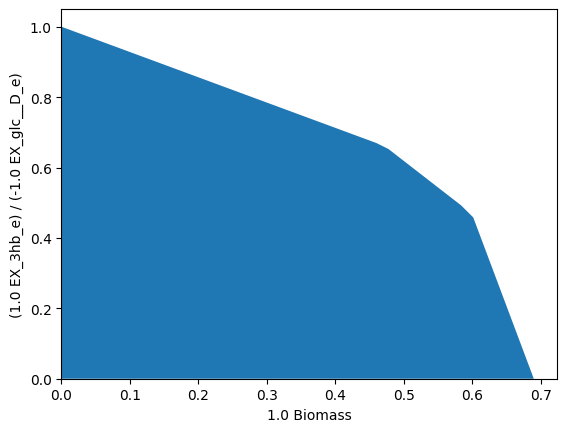

In [54]:
# plot the yield space

sd.plot_flux_space(coli_PHB, ('Biomass',('EX_3hb_e','-EX_glc__D_e')));

In [56]:
# set the minimum growth rate (h-1) and minimum product yield (mmol/mmol)

min_3hb_yield = 0.73
min_growth = 0.35
module_suppress = sd.SDModule(coli_PHB,sd.names.SUPPRESS,constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0')
module_protect  = sd.SDModule(coli_PHB,sd.names.PROTECT, constraints=f'Biomass >= {min_growth}')

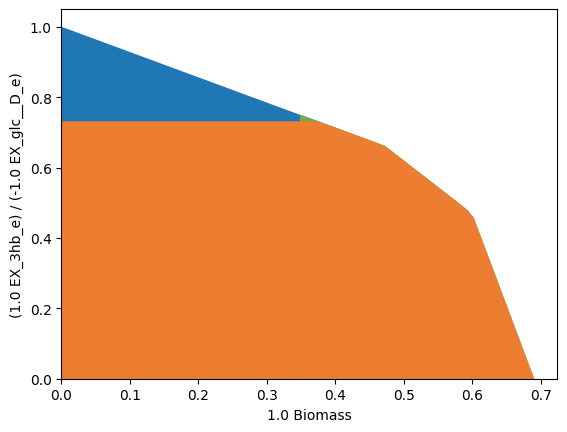

In [57]:
# plot the are to be protected and area to be suppressed

import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               show=False);
_,          _,      plot2 = sd.plot_flux_space(coli_PHB,
                                               (f'Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               constraints=f'Biomass >= {min_growth}',
                                               show=False);
plot2.set_facecolor('#70AD47')
plot2.set_edgecolor('#70AD47')
# pGCP design plot
_,          _,      plot3 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0',
                                               show=False);
plot3.set_facecolor('#ED7D31')
plot3.set_edgecolor('#ED7D31')
# adjust axes limits and show plot
plot3.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot3.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

In [59]:
# run he MCS simulation

import logging
logging.basicConfig(level=logging.INFO)

# allow all gene knockouts 
gko_cost = {g.name:1 for g in coli_PHB.genes}


# possible knockout of O2
ko_cost = {'EX_o2_e': 1}

# Compute strain designs
sols = sd.compute_strain_designs(coli_PHB,
                                 sd_modules = [module_suppress, module_protect],
                                 max_solutions = 1,
                                 max_cost = 16,
                                 ko_cost = ko_cost,
                                 gko_cost = gko_cost,
                                 solution_approach = sd.names.ANY)
# Print solutions
print(f"One compressed solution with cost {sols.sd_cost[0]} found and "+\
      f"expanded to {len(sols.reaction_sd)} solutions in the uncompressed network.")
print(f"Example intervention set: {['+'+s if v>0 else '-'+s for s,v in sols.gene_sd[0].items() if v!=0]}")
print(f"the solutions are: {sols.gene_sd} ")

INFO:root:Preparing strain design computation.
INFO:root:  Using random seed 18651
INFO:root:  Using gurobi for solving LPs during preprocessing.
INFO:root:  FVA to identify blocked reactions and irreversibilities.
INFO:root:  FVA(s) to identify essential reactions.
INFO:root:Preprocessing GPR rules (356 genes, 318 gpr rules).
INFO:root:  Simplifyied to 174 genes and 114 gpr rules.
INFO:root:  Extending metabolic network with gpr associations.
INFO:root:Compressing Network (703 reactions).
INFO:straindesign.compression:  Removing blocked reactions.
INFO:straindesign.compression:  Converting coefficients to rationals.
INFO:straindesign.compression:  Removing conservation relations.
INFO:straindesign.compression:  Compression 1: Lumping coupled reactions.
INFO:straindesign.compression:Compression complete: 5 iterations, 8 zero-flux, 47 contradicting, 472 coupled, 358 unused metabolites
INFO:straindesign.compression:  Reduced to 300 reactions.
INFO:straindesign.compression:  Compression 2

One compressed solution with cost 16.0 found and expanded to 32 solutions in the uncompressed network.
Example intervention set: ['-adhE', '-aceA', '-satP', '-kgtP', '-gltP', '-ldhA', '-frdD', '-pgl', '-sucA', '-pntB', '-mhpF', '-G_b2455', '-ybiV', '-G_b2293', '-G_b0598', '-G_b4354']
the solutions are: [{'adhE': -1.0, 'aceA': -1.0, 'satP': -1.0, 'kgtP': -1.0, 'gltP': -1.0, 'ldhA': -1.0, 'frdD': -1.0, 'pgl': -1.0, 'sucA': -1.0, 'pntB': -1.0, 'mhpF': -1.0, 'G_b2455': -1.0, 'ybiV': -1.0, 'G_b2293': -1.0, 'G_b0598': -1.0, 'G_b4354': -1.0}, {'adhE': -1.0, 'aceA': -1.0, 'satP': -1.0, 'kgtP': -1.0, 'gltP': -1.0, 'ldhA': -1.0, 'frdD': -1.0, 'pgl': -1.0, 'sucA': -1.0, 'pntA': -1.0, 'mhpF': -1.0, 'G_b2455': -1.0, 'ybiV': -1.0, 'G_b2293': -1.0, 'G_b0598': -1.0, 'G_b4354': -1.0}, {'adhE': -1.0, 'aceA': -1.0, 'satP': -1.0, 'kgtP': -1.0, 'gltP': -1.0, 'ldhA': -1.0, 'frdD': -1.0, 'pgl': -1.0, 'sucB': -1.0, 'pntB': -1.0, 'mhpF': -1.0, 'G_b2455': -1.0, 'ybiV': -1.0, 'G_b2293': -1.0, 'G_b0598': -1.0, 'G

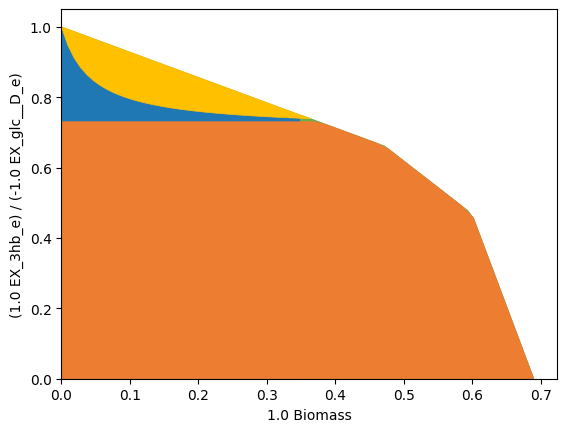

In [60]:
# plot the computed strain design 

import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               show=False);
_,          _,      plot2 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               constraints=f'Biomass>={min_growth}',
                                               show=False);
plot2.set_facecolor('#70AD47')
plot2.set_edgecolor('#70AD47')
# pGCP design plot
_,          _,      plot3 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=f'EX_3hb_e + {min_3hb_yield} EX_glc__D_e <= 0',
                                               show=False);
plot3.set_facecolor('#ED7D31')
plot3.set_edgecolor('#ED7D31')
# plotting designed strain
interventions = [[{s:1.0},'=',0.0] for s,v in sols.reaction_sd[0].items() if v < 1]
_,          _,      plot4 = sd.plot_flux_space(coli_PHB,
                                               ('Biomass',('EX_3hb_e','-EX_glc__D_e')),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=interventions,
                                               show=False);
plot4.set_facecolor('#FFC000')
plot4.set_edgecolor('#FFC000')
# adjust axes limits and show plot
plot4.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot4.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

In [1]:
# testing MCS solutions on E. coli model iCH360 model

# Import necessary packages
import straindesign as sd
import cobra

# If available, set the solver to cplex or gurobi. This will increase the chances
# of sucess enormously
cobra.Configuration().solver = 'gurobi'

# import the microorganism metabolic model
coli = cobra.io.load_json_model('iCH360_PHB.json')

# Create copy of model to which pathway will be added
coli_PHB = coli.copy()



# Glucose, glycerol, xylose, and oxygen uptake
coli_PHB.reactions.EX_glc__D_e.bounds = -10.5, 1000
#coli_PHB.reactions.EX_glyc_e.bounds = -13, 1000
#coli_PHB.reactions.EX_xyl__D_e.bounds = -7.5, 1000
coli_PHB.reactions.EX_o2_e.bounds = -15, 1000


# Verify that pathway is operational
sol = sd.fba(coli_PHB,obj='EX_3hb_e',obj_sense='max')
print(f"Maximum possible PHB synthesis rate: {sol.objective_value}.")


Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-12
Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpx8vbbxe2.lp
Reading time = 0.02 seconds
: 309 rows, 710 columns, 3020 nonzeros
Maximum possible PHB synthesis rate: 10.5.


In [62]:
# check uptake and secretion fluxes

modeltest = coli_PHB.copy()
sol = sd.fba(modeltest)
print(f"rate is: {sol.objective_value}.")
modeltest.summary()

Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpd19xrsuc.lp


INFO:gurobipy.gurobipy:Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpd19xrsuc.lp


Reading time = 0.03 seconds


INFO:gurobipy.gurobipy:Reading time = 0.03 seconds


: 309 rows, 710 columns, 3020 nonzeros


INFO:gurobipy.gurobipy:: 309 rows, 710 columns, 3020 nonzeros
INFO:cobra.summary.model_summary:Generating new parsimonious flux distribution.


rate is: 0.6899644461355737.


Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10.5,6,100.00%
nh4_e,EX_nh4_e,7.445,0,0.00%
o2_e,EX_o2_e,15,0,0.00%
pi_e,EX_pi_e,0.6648,0,0.00%
so4_e,EX_so4_e,0.1726,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
ac_e,EX_ac_e,-9.125,2,52.56%
co2_e,EX_co2_e,-16.47,1,47.43%
for_e,EX_for_e,-0.0009232,1,0.00%
h2o_e,EX_h2o_e,-34.66,0,0.00%


In [2]:
# gene deletions


modeltest = coli_PHB.copy()



# choose the genes to delete 

# PHB on glucose:


genes_to_delete = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'pntA', 'pta', 'eutD'] 



# PHB on glycerol:


#genes_to_delete = ['pykA', 'pykF', 'G_b2843', 'pgi', 'aceA', 'kgtP', 'G_b4354', 'G_b0598', 'pta', 'eutD', 'sucC', 'cyoD']




# PHB on xylose:

#genes_to_delete = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'cyoD', 'pta', 'eutD'] 



# Remove reactions associated with the genes
for gene_name in genes_to_delete:
    found_gene = None
    for gene in modeltest.genes:
        if gene_name == gene.name:
            found_gene = gene
            break
    if found_gene:
        associated_reactions = found_gene.reactions
        modeltest.remove_reactions(associated_reactions)
    else:
        print(f"Gene '{gene_name}' not found in the model.")

# Step 4: Check for consistency
if not modeltest.slim_optimize():
    print("Model is not feasible after gene deletion.")
else:
    print("Gene deletion successful.")

Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpza070uoe.lp
Reading time = 0.02 seconds
: 309 rows, 710 columns, 3020 nonzeros
Gene deletion successful.


In [ ]:
# Get information about the reactions linked to the genes that will be deleted


modeltest = coli_PHB.copy()

gene_name_to_id = {gene.name: gene.id for gene in modeltest.genes}

gene_names_of_interest = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'pntA', 'pta', 'eutD']



gene_ids_of_interest = [gene_name_to_id[name] for name in gene_names_of_interest if name in gene_name_to_id]


reactions_linked = []

for reaction in modeltest.reactions:
    # Check if any of the gene IDs are in the reaction's genes
    if any(gene_id in [g.id for g in reaction.genes] for gene_id in gene_ids_of_interest):
        reactions_linked.append(reaction.id)

print(f"Reactions linked to genes {gene_names_of_interest}: {reactions_linked}")


for reaction_id in reactions_linked:
    reaction = modeltest.reactions.get_by_id(reaction_id)
    print(f"Reaction ID: {reaction.id}")
    print(f"Reaction Name: {reaction.name}")
    print(f"Reaction Formula: {reaction.reaction}")
    print(f"GPR relationship: {reaction.gene_reaction_rule}")
    print("\n")

In [3]:
# check uptake and secretion fluxes after gene deletions to confirm the MCS solution

sol = sd.fba(modeltest)
print(f"rate is: {sol.objective_value}.")
modeltest.summary()

rate is: 0.36756417611133135.


Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10.5,6,100.00%
nh4_e,EX_nh4_e,3.966,0,0.00%
o2_e,EX_o2_e,12.43,0,0.00%
pi_e,EX_pi_e,0.3542,0,0.00%
so4_e,EX_so4_e,0.09196,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
p3hb_e,EX_3hb_e,-7.622,4,63.60%
ac_e,EX_ac_e,-0.2134,2,0.89%
co2_e,EX_co2_e,-17.02,1,35.51%
for_e,EX_for_e,-0.0004918,1,0.00%


In [3]:
# check minimum and maximum flux on the reaction of interest


from cobra.flux_analysis import flux_variability_analysis


# Run FVA with a fraction of optimal flux set to 1.0
fva_results = flux_variability_analysis(modeltest, fraction_of_optimum=1.0)

# Choose the reaction ID for which you want to get FVA results
reaction_id = "EX_3hb_e"  

# Get FVA results for the chosen reaction
reaction_fva = fva_results.loc[reaction_id]

print(reaction_fva)

minimum    7.621563
maximum    7.621563
Name: EX_3hb_e, dtype: float64


In [ ]:
# Saves the results of a FVA simulation in a .json file that can be uploaded to IMFler online tool for flux visualization


# import packages
import json
from pathlib import Path



# Retrives results from FVA simulation
FVA_DATAFRAME   = fva_results          
OUTPUT_FILE     = "fva_results_imfler.json"  
ROUND_DIGITS    = 10  # decimal precision (None = no rounding)



# defines function

def fva_to_imfler(fva_df, output_path=OUTPUT_FILE, round_digits=ROUND_DIGITS):
    """Convert a StrainDesign/COBRApy FVA DataFrame to IMFLer-compatible JSON."""

    # Validate columns
    required = {"minimum", "maximum"}
    missing  = required - set(fva_df.columns)
    if missing:
        raise ValueError(
            f"DataFrame is missing required columns: {missing}\n"
            f"Found: {list(fva_df.columns)}"
        )

    # Build IMFLer format: { "minimum": {rxn_id: value, ...}, "maximum": {rxn_id: value, ...} }
    minimum = {}
    maximum = {}
    for rxn_id, row in fva_df.iterrows():
        lo = float(row["minimum"])
        hi = float(row["maximum"])
        if round_digits is not None:
            lo, hi = round(lo, round_digits), round(hi, round_digits)
        minimum[str(rxn_id)] = lo
        maximum[str(rxn_id)] = hi

    data = {"minimum": minimum, "maximum": maximum}

    # Write JSON
    out = Path(output_path)
    with open(out, "w") as f:
        json.dump(data, f, indent=2)

    print(f"✓ {len(minimum)} reactions exported → {out.resolve()}")
    print(f"\nPreview (first 5 reactions):")
    preview_min = dict(list(minimum.items())[:5])
    preview_max = dict(list(maximum.items())[:5])
    print(json.dumps({"minimum": preview_min, "maximum": preview_max}, indent=2))
    print(f"\n→ Load '{out.name}' in IMFLer: Results > Load FVA results JSON")
    print(  "  https://lv-csbg.github.io/IMFLer/")

    return data

# calls function and saves .json file
imfler_data = fva_to_imfler(FVA_DATAFRAME)

✓ 346 reactions exported → C:\Users\Lenovo\Documents\PhD\Artigo Doutorado\Artigo 2 -batelada alimentada\fva_results_imfler.json

Preview (first 5 reactions):
{
  "minimum": {
    "NDPK5": 0.0099304813,
    "SHK3Dr": 0.1396758572,
    "NDPK6": 0.0096176842,
    "NDPK8": 0.0096176842,
    "DHORTS": -0.1215883916
  },
  "maximum": {
    "NDPK5": 0.0099304813,
    "SHK3Dr": 0.1396758572,
    "NDPK6": 0.0096176842,
    "NDPK8": 0.0096176842,
    "DHORTS": -0.1215883916
  }
}

→ Load 'fva_results_imfler.json' in IMFLer: Results > Load FVA results JSON
  https://lv-csbg.github.io/IMFLer/


In [ ]:
# testing MCS solutions on E. coli model EC_iCH360 model

# Import necessary packages
import straindesign as sd
import cobra

# If available, set the solver to cplex or gurobi. This will increase the chances
# of sucess enormously
cobra.Configuration().solver = 'gurobi'

# import the microorganism metabolic model
coli = cobra.io.load_json_model('EC_iCH360_PHB.json')

# Create copy of model to which pathway will be added
coli_PHB = coli.copy()



# Glucose, glycerol, xylose, and oxygen uptake
coli_PHB.reactions.EX_glc__D_e_bw.bounds = 0, 10.5 
coli_PHB.reactions.EX_glc__D_e_fw.bounds = 0, 0 
coli_PHB.reactions.EX_o2_e_bw.bounds = 0, 15
#coli_PHB.reactions.EX_glyc_e_bw.bounds = 0, 13 
#coli_PHB.reactions.EX_xyl__D_e_bw.bounds = 0, 7.5
#coli_PHB.reactions.Biomass_fw.bounds = 0.3, 1000 


# Verify that pathway is operational
sol = sd.fba(coli_PHB,obj='EX_3hb_e',obj_sense='max')
print(f"Maximum possible PHB synthesis rate: {sol.objective_value}.")


Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmp8b91alxc.lp


INFO:gurobipy.gurobipy:Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmp8b91alxc.lp


Reading time = 0.02 seconds


INFO:gurobipy.gurobipy:Reading time = 0.02 seconds


: 310 rows, 1022 columns, 4848 nonzeros


INFO:gurobipy.gurobipy:: 310 rows, 1022 columns, 4848 nonzeros


Maximum possible PHB synthesis rate: 10.5.


In [ ]:
# check uptake and secretion fluxes

modeltest = coli_PHB.copy()
sol = sd.fba(modeltest)
print(f"rate is: {sol.objective_value}.")
modeltest.summary()

In [67]:
# gene deletions


modeltest = coli_PHB.copy()



# choose the genes to delete 

# PHB on glucose:


genes_to_delete = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'pntA', 'pta', 'eutD'] 



# PHB on glycerol:


#genes_to_delete = ['pykA', 'pykF', 'G_b2843', 'pgi', 'aceA', 'kgtP', 'G_b4354', 'G_b0598', 'pta', 'eutD', 'sucC', 'cyoD']




# PHB on xylose:

#genes_to_delete = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'cyoD', 'pta', 'eutD'] 



# Remove reactions associated with the genes
for gene_name in genes_to_delete:
    found_gene = None
    for gene in modeltest.genes:
        if gene_name == gene.name:
            found_gene = gene
            break
    if found_gene:
        associated_reactions = found_gene.reactions
        modeltest.remove_reactions(associated_reactions)
    else:
        print(f"Gene '{gene_name}' not found in the model.")

# Step 4: Check for consistency
if not modeltest.slim_optimize():
    print("Model is not feasible after gene deletion.")
else:
    print("Gene deletion successful.")

Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpewc4fh4z.lp


INFO:gurobipy.gurobipy:Read LP format model from file C:\Users\Lenovo\AppData\Local\Temp\tmpewc4fh4z.lp


Reading time = 0.03 seconds


INFO:gurobipy.gurobipy:Reading time = 0.03 seconds


: 310 rows, 1022 columns, 4848 nonzeros


INFO:gurobipy.gurobipy:: 310 rows, 1022 columns, 4848 nonzeros


Gene deletion successful.


In [ ]:
# Get information about the reactions linked to the genes that will be deleted


modeltest = coli_PHB.copy()

gene_name_to_id = {gene.name: gene.id for gene in modeltest.genes}

gene_names_of_interest = ['mhpF', 'G_b2455', 'adhE', 'aceA', 'sucA', 'zwf', 'kgtP', 'G_b0598', 'G_b4354', 'pntA', 'pta', 'eutD']



gene_ids_of_interest = [gene_name_to_id[name] for name in gene_names_of_interest if name in gene_name_to_id]


reactions_linked = []

for reaction in modeltest.reactions:
    # Check if any of the gene IDs are in the reaction's genes
    if any(gene_id in [g.id for g in reaction.genes] for gene_id in gene_ids_of_interest):
        reactions_linked.append(reaction.id)

print(f"Reactions linked to genes {gene_names_of_interest}: {reactions_linked}")


for reaction_id in reactions_linked:
    reaction = modeltest.reactions.get_by_id(reaction_id)
    print(f"Reaction ID: {reaction.id}")
    print(f"Reaction Name: {reaction.name}")
    print(f"Reaction Formula: {reaction.reaction}")
    print(f"GPR relationship: {reaction.gene_reaction_rule}")
    print("\n")

In [68]:
# check uptake and secretion fluxes after gene deletions to confirm the MCS solution

sol = sd.fba(modeltest)
print(f"rate is: {sol.objective_value}.")
modeltest.summary()

INFO:cobra.summary.model_summary:Generating new parsimonious flux distribution.


rate is: 0.30920338383436213.


Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e_bw,9.007,6,100.00%
nh4_e,EX_nh4_e_bw,3.336,0,0.00%
o2_e,EX_o2_e_bw,10.72,0,0.00%
pi_e,EX_pi_e_bw,0.2979,0,0.00%
so4_e,EX_so4_e_bw,0.07736,0,0.00%
enzyme_pool,enzyme_pool_supply,0.2818,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
p3hb_e,EX_3hb_e,-6.586,4,63.68%
ac_e,EX_ac_e_fw,-0.1795,2,0.87%
co2_e,EX_co2_e_fw,-14.67,1,35.45%


In [69]:
# check minimum and maximum flux on the reaction of interest


from cobra.flux_analysis import flux_variability_analysis


# Run FVA with a fraction of optimal flux set to 1.0
fva_results = flux_variability_analysis(modeltest, fraction_of_optimum=1.0)

# Choose the reaction ID for which you want to get FVA results
reaction_id = "EX_3hb_e"  

# Get FVA results for the chosen reaction
reaction_fva = fva_results.loc[reaction_id]

print(reaction_fva)

minimum    6.585706
maximum    6.585706
Name: EX_3hb_e, dtype: float64
